In [1]:
import pandas as pd

df = pd.read_excel("COVID-19-geographic-disbtribution-worldwide.xlsx")
print(df.head())
print(df.columns)

     dateRep  day  month  year  cases  deaths countriesAndTerritories geoId  \
0 2020-12-14   14     12  2020    746       6             Afghanistan    AF   
1 2020-12-13   13     12  2020    298       9             Afghanistan    AF   
2 2020-12-12   12     12  2020    113      11             Afghanistan    AF   
3 2020-12-11   11     12  2020     63      10             Afghanistan    AF   
4 2020-12-10   10     12  2020    202      16             Afghanistan    AF   

  countryterritoryCode  popData2019 continentExp  \
0                  AFG   38041757.0         Asia   
1                  AFG   38041757.0         Asia   
2                  AFG   38041757.0         Asia   
3                  AFG   38041757.0         Asia   
4                  AFG   38041757.0         Asia   

   Cumulative_number_for_14_days_of_COVID-19_cases_per_100000  
0                                           9.013779           
1                                           7.052776           
2                   

In [20]:
africa = df[df["continentExp"] == "Africa"]
print(africa.head())
print(africa.shape)

       dateRep  day  month  year  cases  deaths countriesAndTerritories geoId  \
621 2020-12-14   14     12  2020    464      12                 Algeria    DZ   
622 2020-12-13   13     12  2020    517       9                 Algeria    DZ   
623 2020-12-12   12     12  2020    542      11                 Algeria    DZ   
624 2020-12-11   11     12  2020    565      10                 Algeria    DZ   
625 2020-12-10   10     12  2020    598      15                 Algeria    DZ   

    countryterritoryCode  popData2019 continentExp  \
621                  DZA   43053054.0       Africa   
622                  DZA   43053054.0       Africa   
623                  DZA   43053054.0       Africa   
624                  DZA   43053054.0       Africa   
625                  DZA   43053054.0       Africa   

     Cumulative_number_for_14_days_of_COVID-19_cases_per_100000  
621                                          22.950753           
622                                          24.216633  

In [10]:
print(df["continentExp"].unique())

['Asia' 'Europe' 'Africa' 'America' 'Oceania' 'Other']


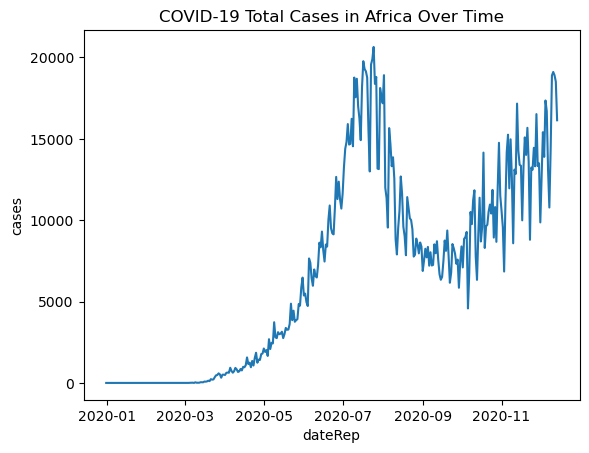

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

africa_daily = africa.groupby("dateRep")["cases"].sum().reset_index()

sns.lineplot(data=africa_daily, x="dateRep", y="cases")
plt.title("COVID-19 Total Cases in Africa Over Time")
plt.xticks( )
plt.show()

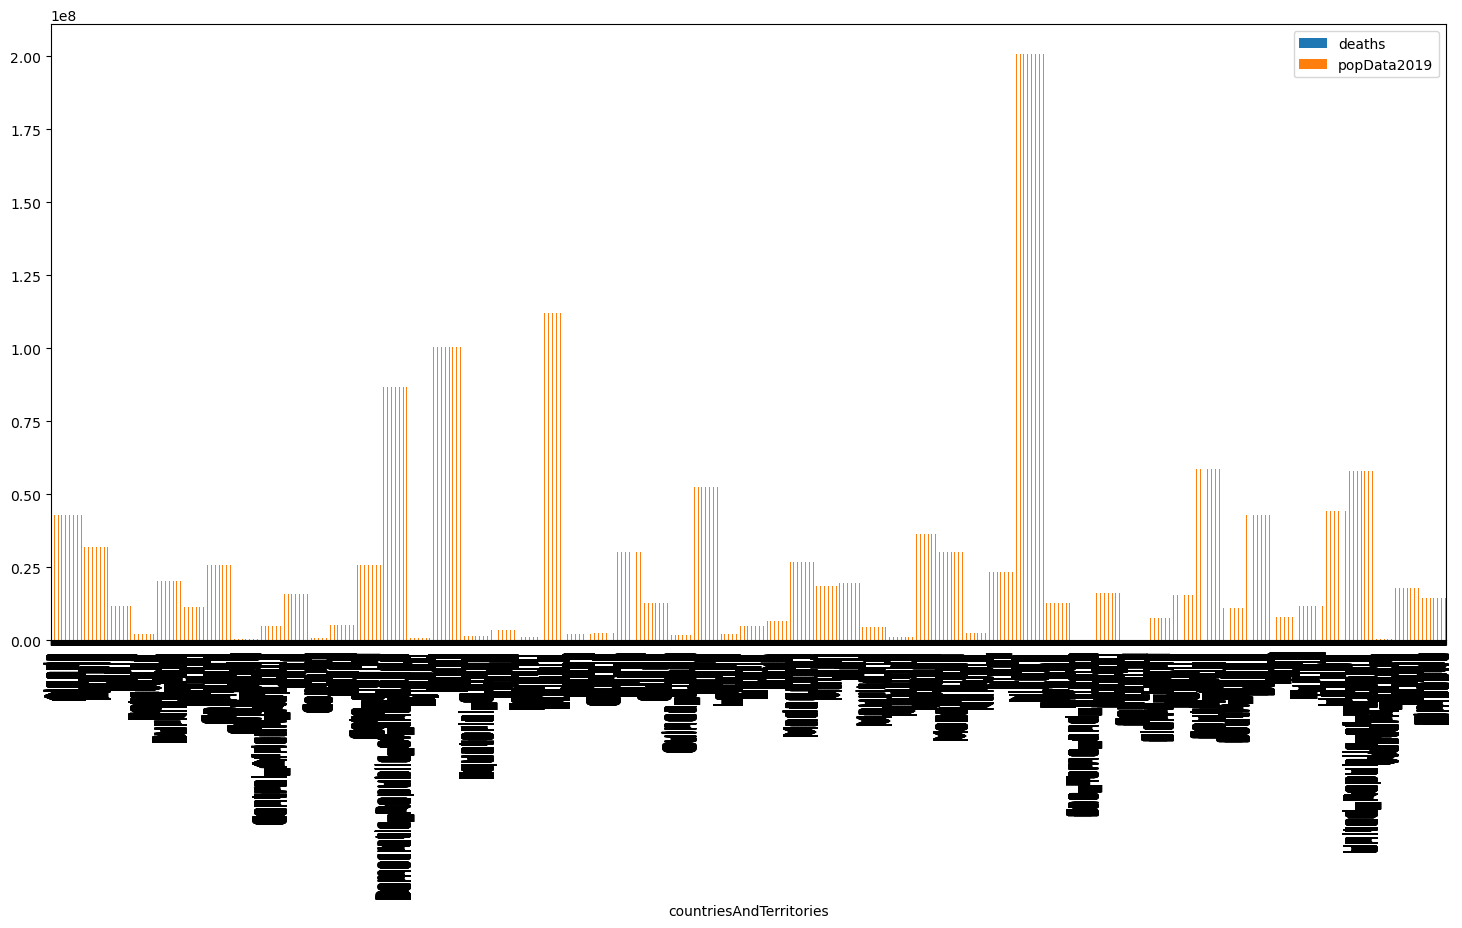

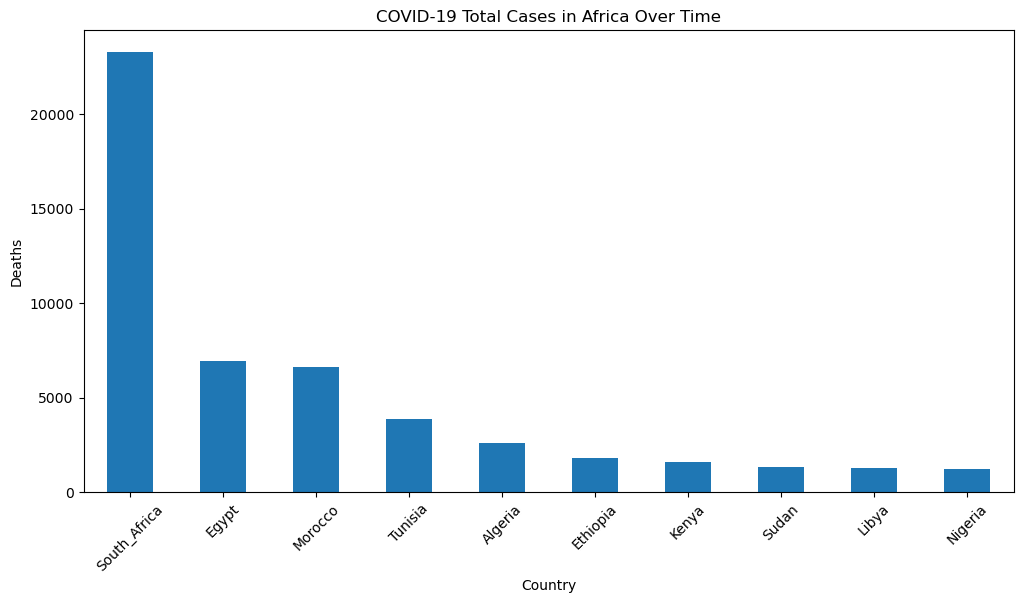

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter Africa
africa_daily = df[df["continentExp"] == "Africa"]

# Get total deaths by country
deaths_by_country = africa.groupby("countriesAndTerritories")["deaths"].sum()

africa_daily.plot(
    x="countriesAndTerritories",
    y=["deaths", "popData2019"],
    kind="bar",
    figsize=(18,8)
)


plt.figure(figsize=(12,6))
top10.plot(kind="bar")
plt.title("COVID-19 Total Cases in Africa Over Time")
plt.xlabel("Country")
plt.ylabel("Deaths")
plt.xticks(rotation=45)
plt.show()

In [35]:
!pip install dash

In [42]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import pandas as pd

# Filter Africa
africa = df[df["continentExp"] == "Africa"]

app = Dash(__name__)

app.layout = html.Div([
    html.H1("COVID-19 Deaths in African Countries"),

    dcc.Dropdown(
        id="dropdown",
        options=sorted(africa["countriesAndTerritories"].unique()),
        value=africa["countriesAndTerritories"].unique()[0],
        clearable=False
    ),

    dcc.Graph(id="graph")
])

@app.callback(
    Output("graph", "figure"),
    Input("dropdown", "value")
)
def update_chart(country):

    country_df = africa[
        africa["countriesAndTerritories"] == country
    ]

    fig = px.bar(
        country_df,
        x="dateRep",
        y="deaths",
        title=f"COVID-19 Deaths in {country}"
    )

    return fig

app.run(debug=True, port=8051)

In [43]:
df = df.dropna(subset=["continentExp", "countriesAndTerritories", "deaths", "dateRep"])

app = Dash(__name__)

app.layout = html.Div([
    html.H1("COVID-19 Dashboard (Continent → Country → Deaths)"),

    # Continent dropdown
    dcc.Dropdown(
        id="continent-dropdown",
        options=sorted(df["continentExp"].unique()),
        value="Africa",
        clearable=False
    ),

_IncompleteInputError: incomplete input (21638451.py, line 14)

In [44]:
@app.callback(
    Output("country-dropdown", "options"),
    Output("country-dropdown", "value"),
    Input("continent-dropdown", "value")
)
def update_countries(continent):
    filtered = df[df["continentExp"] == continent]
    countries = sorted(filtered["countriesAndTerritories"].unique())

    return (
        [{"label": c, "value": c} for c in countries],
        countries[0] if countries else None
    )


# Update graph based on country
@app.callback(
    Output("graph", "figure"),
    Input("country-dropdown", "value"),
    Input("continent-dropdown", "value")
)
def update_graph(country, continent):

    filtered = df[
        (df["continentExp"] == continent) &
        (df["countriesAndTerritories"] == country)
    ]

    # Sort by date (important)
    filtered = filtered.sort_values("dateRep")

    fig = px.line(
        filtered,
        x="dateRep",
        y="deaths",
        title=f"COVID-19 Deaths in {country} ({continent})",
        markers=True
    )

    return fig


app.run(debug=True, port=8051)

AssertionError: The setup method 'errorhandler' can no longer be called on the application. It has already handled its first request, any changes will not be applied consistently.
Make sure all imports, decorators, functions, etc. needed to set up the application are done before running it.